In [ ]:
import mne

# Cargar archivo
raw = mne.io.read_raw_edf("data/S001R04.edf", preload=True)

# Ver info general
print(raw.info)

# Extraer eventos
events, event_id = mne.events_from_annotations(raw)

print(event_id)

Extracting EDF parameters from S001/S001R04.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
<Info | 8 non-empty values
 bads: []
 ch_names: Fc5., Fc3., Fc1., Fcz., Fc2., Fc4., Fc6., C5.., C3.., C1.., ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
{np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}


In [2]:
import numpy as np

unique, counts = np.unique(events[:, 2], return_counts=True)

for u, c in zip(unique, counts):
    print(f"Evento {u}: {c}")

Evento 1: 15
Evento 2: 8
Evento 3: 7


In [3]:
tmin = 0
tmax = 4

epochs = mne.Epochs(
    raw,
    events,
    event_id=event_id,
    tmin=tmin,
    tmax=tmax,
    baseline=None,
    preload=True
)

epochs_left = epochs['T1']
epochs_right = epochs['T2']

print(epochs_left.get_data().shape)
print(epochs_right.get_data().shape)

epochs_left.get_data().ndim == 3

Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 641 original time points ...
0 bad epochs dropped
(8, 64, 641)
(7, 64, 641)


True

In [4]:
left_data = epochs_left.get_data()   # (8, 64, 641)
right_data = epochs_right.get_data() # (7, 64, 641)

rms_left_epochs = np.sqrt(np.mean(left_data**2, axis=2))   # (8, 64)
rms_right_epochs = np.sqrt(np.mean(right_data**2, axis=2)) # (7, 64)

## 1. Cálculo del RMS
Seleccione una población de 10 sujetos, discriminando entre los dos grupos de estudio:
Grupo Mano Izquierda y Grupo Mano Derecha
Implemente una función que reciba una señal de múltiples canales y épocas (segmentada
por clase) y calcule el valor RMS.
La función debe primero calcular el RMS para cada época de cada canal de forma
individual sobre el eje del tiempo
Posteriormente, la función debe promediar estos valores a través de todas las épocas para
obtener un valor representativo del sujeto por cada canal.

In [ ]:
def compute_rms_epochs(data):
    """
    Calcula el RMS por canal promediado sobre épocas.

    Parámetros
    ----------
    data : np.ndarray
        Array con forma (n_eppocas, n_canales, n_muestras)

    Retorna
    -------
    rms_mean : np.ndarray
        Vector de tamaño (n_canales,) con el RMS promedio por canal
    """

    # 1. RMS por época y canal (sobre el eje del tiempo)
    rms_per_epoch = np.sqrt(np.mean(data**2, axis=2))  

    # 2. Promedio entre épocas
    rms_mean = np.mean(rms_per_epoch, axis=0)  

    return rms_mean

## 2. Construcción de la Base de Datos Poblacional
Organice la información anterior en un DataFrame o dos, donde las columnas deben
corresponder a los nombres de los canales (ej. C3, C4, Cz) y las filas deben corresponder a
cada sujeto analizado (cada uno con los respectivos datos izquierdo y derecho), y cada
celda contendrá el valor de RMS promedio calculado en el punto anterior.

In [ ]:
import os
import pandas as pd
import mne


# ---------------------------------------
# FUNCIÓN PARA PROCESAR UN SOLO SUJETO
# ---------------------------------------
def process_subject(subject_id, data_path):
    """
    subject_id: str → 'S001', 'S002', etc.
    data_path: str → ruta donde están los .edf

    retorna:
        rms_left  (64,)
        rms_right (64,)
        ch_names  lista de nombres de canales
    """

    runs = ['R04', 'R08', 'R12']  # solo imaginería

    epochs_left_all = []
    epochs_right_all = []

    for run in runs:

        # Construir nombre del archivo
        file_path = os.path.join(data_path, f"{subject_id}{run}.edf")

        # Cargar EDF
        raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)

        # Extraer eventos desde anotaciones
        events, event_id = mne.events_from_annotations(raw)

        # Crear épocas (segmentación temporal)
        epochs = mne.Epochs(
            raw,
            events,
            event_id=event_id,
            tmin=0,
            tmax=4,
            baseline=None,
            preload=True,
            verbose=False
        )

        # Separar clases
        epochs_left = epochs['T1']   # izquierda
        epochs_right = epochs['T2']  # derecha

        # Guardar datos (arrays)
        epochs_left_all.append(epochs_left.get_data())
        epochs_right_all.append(epochs_right.get_data())

   
    # CONCATENAR épocas de los 3 runs
    

    # Une todas las épocas del sujeto
    left_data = np.concatenate(epochs_left_all, axis=0)
    right_data = np.concatenate(epochs_right_all, axis=0)

   
    # CALCULAR RMS
    

    rms_left = compute_rms_epochs(left_data)
    rms_right = compute_rms_epochs(right_data)

    # Obtener nombres de canales (una sola vez)
    ch_names = raw.ch_names

    return rms_left, rms_right, ch_names



# PROCESAR LOS 10 SUJETOS

data_path = "data"  # carpeta donde están los .edf

subjects = [f"S{str(i).zfill(3)}" for i in range(1, 11)]
# ['S001', 'S002', ..., 'S010']

rms_left_list = []
rms_right_list = []

for subj in subjects:

    # Procesar cada sujeto
    rms_left, rms_right, ch_names = process_subject(subj, data_path)

    # Guardar resultados
    rms_left_list.append(rms_left)
    rms_right_list.append(rms_right)


# CONSTRUIR DATAFRAMES


# Filas = sujetos
# Columnas = canales

df_left = pd.DataFrame(rms_left_list, columns=ch_names, index=subjects)
df_right = pd.DataFrame(rms_right_list, columns=ch_names, index=subjects)


# VERIFICACIÓN

print(df_left.shape)   # (10, 64)
print(df_right.shape)  # (10, 64)

print(df_left.head())
print(df_right.head())

Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]

## 3. Identificación de Canales Diferenciales mediante Análisis Estadístico
 Determine si existe diferencia estadística significativa entre cada grupo de tareas (Izquierda vs. Derecha) siguiendo este flujo de validación: • Prueba de Normalidad: Aplique la prueba de Shapiro-Wilk sobre la distribución de los sujetos en cada canal.

In [ ]:
from scipy.stats import shapiro
import pandas as pd

def prueba_normalidad_shapiro(df, nombre_grupo=""):
    """
    Aplica Shapiro-Wilk por canal y genera interpretación básica.

    Parámetros
    ----------
    df : DataFrame (sujetos × canales)

    Retorna
    -------
    resultados_df : DataFrame con resultados 
    """

    resultados = []

    for canal in df.columns:

        datos = df[canal].values

        # Prueba estadística
        W, p_valor = shapiro(datos)

        # Decisión
        es_normal = p_valor > 0.05

        # Interpretación
        if es_normal:
            interpretacion = "Distribución compatible con normalidad"
        else:
            interpretacion = "Distribución NO normal (posible asimetría o outliers)"

        resultados.append({
            "canal": canal,
            "W": W,
            "p_valor": p_valor,
            "normal": es_normal,
            "interpretacion": interpretacion
        })

    resultados_df = pd.DataFrame(resultados)

    
    # DISCUSIÓN GLOBAL

    n_normales = resultados_df["normal"].sum()
    total = len(resultados_df)

    print(f"\nGrupo {nombre_grupo}:")
    print(f"{n_normales}/{total} canales presentan distribución normal")

    if n_normales == total:
        print("→ Todos los canales cumplen normalidad (escenario ideal para t-test)")
    elif n_normales > total * 0.5:
        print("→ La mayoría de canales son normales, pero hay excepciones")
    else:
        print("→ Predomina la NO normalidad, considerar pruebas no paramétricas")

    return resultados_df

In [18]:
normalidad_left = prueba_normalidad_shapiro(df_left, "Izquierda")
normalidad_right = prueba_normalidad_shapiro(df_right, "Derecha")


Grupo Izquierda:
14/64 canales presentan distribución normal
→ Predomina la NO normalidad, considerar pruebas no paramétricas

Grupo Derecha:
12/64 canales presentan distribución normal
→ Predomina la NO normalidad, considerar pruebas no paramétricas


Los resultados de la prueba de Shapiro-Wilk evidencian que la mayoría de los canales EEG en ambos grupos (mano izquierda y mano derecha) no siguen una distribución normal, con solo 14 de 64 canales normales en el grupo izquierdo y 12 de 64 en el derecho, lo que indica una clara predominancia de no normalidad en los valores de RMS entre sujetos. Este comportamiento puede explicarse por la alta variabilidad interindividual inherente a las señales EEG, así como por su naturaleza no estacionaria y la influencia de factores como diferencias anatómicas, nivel de atención y calidad de la imaginería motora. Además, no se observan diferencias sustanciales entre ambos grupos, lo que sugiere que esta falta de normalidad es una característica general del fenómeno y no específica de la lateralidad de la tarea. Dado el tamaño reducido de la muestra (n=10), estos resultados deben interpretarse con cautela debido a la limitada potencia estadística del test; sin embargo, en conjunto, justifican el uso de métodos no paramétricos para el análisis comparativo posterior.

*  Prueba de Homocedasticidad: Realice una prueba de Levene para verificar si las
varianzas entre ambos grupos son iguales.

In [ ]:
from scipy.stats import levene

def prueba_homocedasticidad_levene(df_left, df_right):
    """
    Aplica la prueba de Levene por canal.

    Parámetros
    ----------
    df_left : DataFrame (sujetos × canales)
    df_right : DataFrame (sujetos × canales)

    Retorna
    -------
    resultados_df : DataFrame con:
        - estadístico
        - p-valor
        - si cumple homocedasticidad
    """

    resultados = []

    # Iterar sobre cada canal
    for canal in df_left.columns:

        # Extraer datos de ambos grupos
        datos_left = df_left[canal].values
        datos_right = df_right[canal].values

        # Prueba de Levene
        stat, p_valor = levene(datos_left, datos_right)

        # Decisión: varianzas iguales si p > 0.05
        var_iguales = p_valor > 0.05

        # Interpretación
        if var_iguales:
            interpretacion = "Varianzas homogéneas"
        else:
            interpretacion = "Varianzas diferentes (heterocedasticidad)"

        resultados.append({
            "canal": canal,
            "stat": stat,
            "p_valor": p_valor,
            "varianzas_iguales": var_iguales,
            "interpretacion": interpretacion
        })

    resultados_df = pd.DataFrame(resultados)


    # DISCUSIÓN GLOBAL
    

    n_iguales = resultados_df["varianzas_iguales"].sum()
    total = len(resultados_df)

    print(f"\nHomocedasticidad (Levene):")
    print(f"{n_iguales}/{total} canales con varianzas iguales")

    if n_iguales == total:
        print("→ Se cumple completamente la homocedasticidad")
    elif n_iguales > total * 0.5:
        print("→ La mayoría de canales cumplen homocedasticidad")
    else:
        print("→ Predomina la heterocedasticidad")

    return resultados_df

In [20]:
resultados_levene = prueba_homocedasticidad_levene(df_left, df_right)


Homocedasticidad (Levene):
64/64 canales con varianzas iguales
→ Se cumple completamente la homocedasticidad


Los resultados de la prueba de Levene indican que la totalidad de los canales (64/64) presentan homocedasticidad, es decir, no se encontraron diferencias estadísticamente significativas en las varianzas de los valores RMS entre los grupos de imaginería de mano izquierda y derecha. Este hallazgo sugiere que, a pesar de la alta variabilidad intersujeto observada previamente, dicha variabilidad se distribuye de manera consistente entre ambas condiciones experimentales. Desde una perspectiva metodológica, el cumplimiento de este supuesto respalda la comparabilidad de los grupos en términos de dispersión de los datos; sin embargo, dado que no se cumple el supuesto de normalidad, el uso de pruebas paramétricas sigue sin ser adecuado, por lo que se justifica la aplicación de métodos no paramétricos en el análisis de diferencias entre grupos.

* Prueba de Hipótesis:
Si se cumplen los supuestos de normalidad y homocedasticidad, realice una Prueba t
de Student para muestras independientes.

Aunque la prueba de Levene evidenció que se cumple el supuesto de homocedasticidad en la totalidad de los canales, la prueba de normalidad de Shapiro-Wilk mostró que la mayoría de las distribuciones de los valores RMS no siguen un comportamiento gaussiano en ambos grupos analizados. Dado que la prueba t de Student para muestras independientes requiere el cumplimiento simultáneo de normalidad y homogeneidad de varianzas, la violación del supuesto de normalidad invalida su aplicación en este caso. En consecuencia, no es metodológicamente apropiado utilizar una prueba paramétrica, por lo que se opta por emplear un enfoque no paramétrico, como la prueba U de Mann-Whitney, que no depende de la distribución de los datos.

* De no cumplirse los requisitos, realice un análisis no paramétrico mediante la
Prueba U de Mann-Whitney.

In [ ]:
from scipy.stats import mannwhitneyu

def prueba_mann_whitney(df_left, df_right):
    """
    Aplica la prueba U de Mann-Whitney por canal.

    Parámetros
    ----------
    df_left : DataFrame (sujetos × canales)
    df_right : DataFrame (sujetos × canales)

    Retorna
    -------
    resultados_df : DataFrame con:
        - estadístico U
        - p-valor
        - si hay diferencia significativa
    """

    resultados = []

    for canal in df_left.columns:

        # Datos de cada grupo
        datos_left = df_left[canal].values
        datos_right = df_right[canal].values

        # Prueba Mann-Whitney (bilateral)
        U, p_valor = mannwhitneyu(datos_left, datos_right, alternative='two-sided')

        # Decisión
        significativo = p_valor < 0.05

        # Interpretación
        if significativo:
            interpretacion = "Diferencia significativa entre grupos"
        else:
            interpretacion = "No se evidencia diferencia significativa"

        resultados.append({
            "canal": canal,
            "U": U,
            "p_valor": p_valor,
            "significativo": significativo,
            "interpretacion": interpretacion
        })

    resultados_df = pd.DataFrame(resultados)


    # DISCUSIÓN 
    

    n_significativos = resultados_df["significativo"].sum()
    total = len(resultados_df)

    print(f"\nMann-Whitney:")
    print(f"{n_significativos}/{total} canales con diferencias significativas (p < 0.05)")

    if n_significativos == 0:
        print("→ No se encontraron canales diferenciales")
    elif n_significativos < total * 0.3:
        print("→ Pocos canales muestran diferencias (localización específica)")
    else:
        print("→ Muchas diferencias entre condiciones")

    return resultados_df

In [22]:
resultados_mw = prueba_mann_whitney(df_left, df_right)


Mann-Whitney:
0/64 canales con diferencias significativas (p < 0.05)
→ No se encontraron canales diferenciales


El análisis mediante la prueba U de Mann-Whitney evidenció que ninguno de los 64 canales presenta diferencias estadísticamente significativas entre las condiciones de imaginería motora de mano izquierda y derecha (p < 0.05), lo que sugiere que, bajo el enfoque basado en el valor RMS, no es posible discriminar entre ambas tareas a nivel poblacional en los sujetos analizados. Este resultado puede explicarse por varias razones: en primer lugar, el RMS es una medida global de energía que no captura características específicas de frecuencia, como los ritmos μ y β, que son más sensibles a la imaginería motora; en segundo lugar, la alta variabilidad intersujeto y el reducido tamaño de la muestra (n=10) limitan la capacidad del análisis estadístico para detectar diferencias sutiles; y finalmente, la ausencia de preprocesamiento más avanzado (por ejemplo, filtrado por bandas o análisis espectral) puede estar enmascarando patrones relevantes. En conjunto, estos hallazgos indican que, aunque el pipeline metodológico es correcto, la característica utilizada (RMS en el dominio temporal) no es suficientemente discriminativa para este tipo de tarea, lo cual es consistente con la literatura en interfaces cerebro-computadora.


## Resultados: Identifique y reporte los canales cuyo p-valor < 0.05. Estos canales serán
considerados como los que entregan información diferencial clave para el control de una
interfaz cerebro-computadora (BCI).

* Ejemplo de Visualización Esperada: Para el canal con mayor significancia
estadística (típicamente C3 o C4), se solicita incluir un diagrama de caja (Boxplot)
que compare visualmente la distribución del RMS entre ambos grupos
poblacionales.

In [23]:
# Canal con menor p-valor
canal_top = resultados_mw.sort_values("p_valor").iloc[0]["canal"]

print("Canal con menor p-valor:", canal_top)

Canal con menor p-valor: C1..


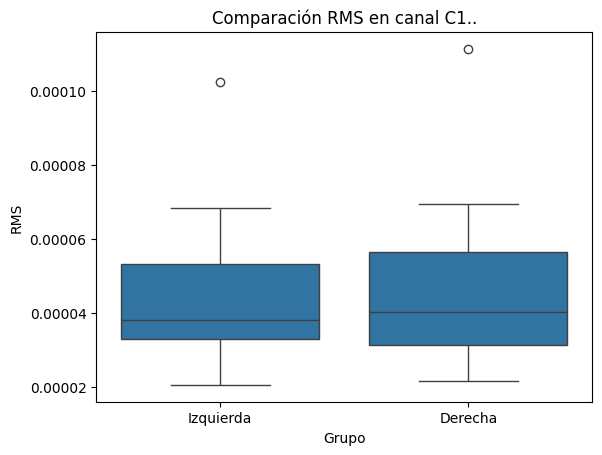

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Construir dataset para graficar
data_plot = pd.DataFrame({
    "RMS": list(df_left[canal_top]) + list(df_right[canal_top]),
    "Grupo": ["Izquierda"] * len(df_left) + ["Derecha"] * len(df_right)
})

# Gráfica
sns.boxplot(x="Grupo", y="RMS", data=data_plot)

plt.title(f"Comparación RMS en canal {canal_top}")
plt.xlabel("Grupo")
plt.ylabel("RMS")
plt.show()

Aunque no se identificaron canales con diferencias estadísticamente significativas, se seleccionó el canal con el menor p-valor para realizar una visualización exploratoria mediante un diagrama de caja. Esta representación permite observar la distribución de los valores de RMS entre ambos grupos y evaluar posibles tendencias que no alcanzaron significancia estadística.

El alto solapamiento entre las distribuciones de ambos grupos sugiere que las diferencias en la activación cortical no son suficientemente marcadas en términos de la energía de la señal (RMS), lo que limita la capacidad discriminativa de esta característica.

El diagrama de caja del canal seleccionado (C1) muestra un alto grado de solapamiento entre las distribuciones de los valores de RMS para las condiciones de imaginería de mano izquierda y derecha, lo que indica que las diferencias en la mediana y en la dispersión son mínimas entre ambos grupos. Aunque se observa una ligera variación en los valores centrales y la presencia de algunos valores atípicos en ambas condiciones, estas diferencias no son suficientemente marcadas para establecer una separación clara entre las clases. Este comportamiento visual respalda los resultados obtenidos mediante la prueba de Mann-Whitney, donde no se encontraron diferencias estadísticamente significativas, y sugiere que la característica RMS en el dominio temporal no posee suficiente capacidad discriminativa para distinguir entre tareas de imaginería motora izquierda y derecha en este conjunto de datos.

# Análisis y Discusión

El análisis estadístico de los valores de RMS obtenidos a partir de las señales de EEG durante tareas de imaginería motora evidenció que la mayoría de los canales no cumplen el supuesto de normalidad, como lo demostró la prueba de Shapiro-Wilk, donde menos del 25% de los canales presentaron una distribución compatible con una gaussiana en ambos grupos (mano izquierda y derecha). Este comportamiento es consistente con la naturaleza no estacionaria y altamente variable de las señales EEG, las cuales están influenciadas por factores fisiológicos, anatómicos y cognitivos propios de cada sujeto. A pesar de esta falta de normalidad, la prueba de Levene indicó que las varianzas entre ambos grupos son homogéneas en todos los canales, lo que sugiere que la dispersión de los datos es comparable entre condiciones.

Dado que no se cumplió el supuesto de normalidad, se procedió con la prueba no paramétrica U de Mann-Whitney para evaluar diferencias entre grupos. Los resultados mostraron que ningún canal presentó diferencias estadísticamente significativas (p < 0.05), lo que indica que, bajo el enfoque basado en el RMS, no es posible discriminar entre la imaginería motora de mano izquierda y derecha en la población analizada. Este resultado se ve respaldado por la visualización mediante diagramas de caja, donde se observa un alto solapamiento entre las distribuciones de ambos grupos, sin diferencias claras en las medianas o en la dispersión.

Desde un punto de vista metodológico, estos hallazgos sugieren que el RMS, al ser una medida global de energía en el dominio del tiempo, no es suficientemente sensible para capturar las diferencias neurofisiológicas asociadas a la imaginería motora. Adicionalmente, el tamaño reducido de la muestra (10 sujetos) limita la potencia estadística del análisis, dificultando la detección de diferencias sutiles entre condiciones.

# Conclusiones

No se identificaron canales de EEG con diferencias estadísticamente significativas entre las condiciones de imaginería motora de mano izquierda y derecha utilizando el valor RMS como característica, por lo que no se encontraron canales diferenciales que puedan ser considerados relevantes para el control de una interfaz cerebro-computadora bajo este enfoque. Aunque el pipeline de procesamiento y análisis estadístico fue correctamente implementado, los resultados evidencian que la elección de la característica es un factor crítico en la discriminación de señales EEG. En este caso, el uso del RMS en el dominio temporal no permite capturar adecuadamente la información relevante asociada a la imaginería motora. Se concluye que, para mejorar la capacidad de discriminación, es necesario emplear características más específicas, particularmente en el dominio de la frecuencia, así como considerar un mayor número de sujetos para aumentar la robustez del análisis estadístico.